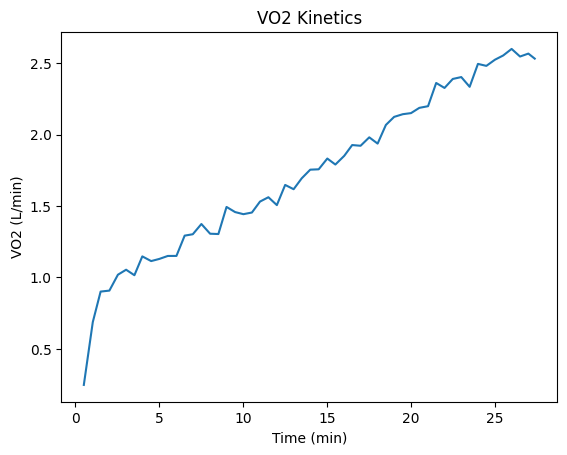

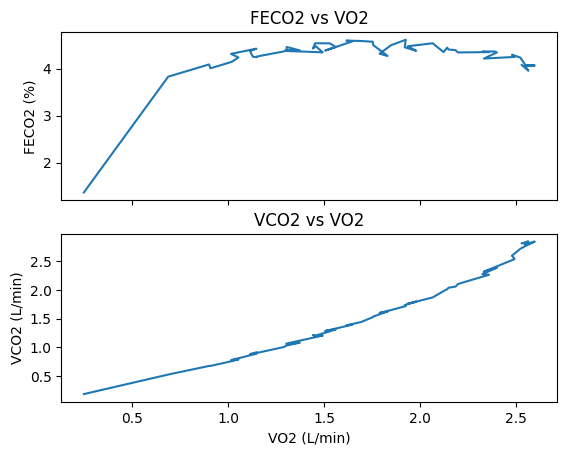

GET VO2: 1.01532805
RCP VO2: 1.926275373


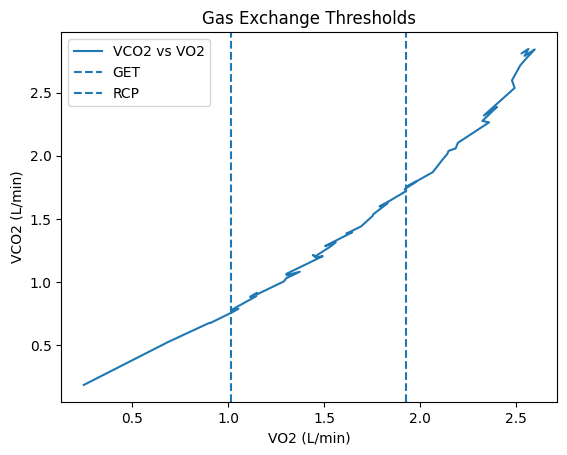

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

# Data & Cleaning
df = pd.read_csv("/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv")

df = df.iloc[3:].reset_index(drop=True)

df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()

# Variables
time = df["TIME"]
vo2 = df["VO2"]
vco2 = df["VCO2"]
feco2 = df["FECO2"]

# Figure
plt.figure()

plt.plot(time, vo2)

plt.xlabel("Time (min)")
plt.ylabel("VO2 (L/min)")
plt.title("VO2 Kinetics")

plt.show()

# Gas Exchange plots
fig, ax = plt.subplots(2, sharex=True)

ax[0].plot(vo2, feco2)
ax[0].set_ylabel("FECO2 (%)")
ax[0].set_title("FECO2 vs VO2")

ax[1].plot(vo2, vco2)
ax[1].set_xlabel("VO2 (L/min)")
ax[1].set_ylabel("VCO2 (L/min)")
ax[1].set_title("VCO2 vs VO2")

plt.show()

# GET

get_index = 0

for i in range(1, len(vo2)):
    if (vco2.iloc[i] - vco2.iloc[i-1]) > (vo2.iloc[i] - vo2.iloc[i-1]):
        get_index = i
        break

get_vo2 = vo2.iloc[get_index]

print("GET VO2:", get_vo2)

# RCP

rcp_index = 0
max_feco2 = feco2.iloc[0]

for i in range(len(feco2)):
    if feco2.iloc[i] > max_feco2:
        max_feco2 = feco2.iloc[i]
        rcp_index = i

rcp_vo2 = vo2.iloc[rcp_index]

print("RCP VO2:", rcp_vo2)

plt.figure()

plt.plot(vo2, vco2, label="VCO2 vs VO2")

plt.axvline(get_vo2, linestyle='--', label="GET")
plt.axvline(rcp_vo2, linestyle='--', label="RCP")

plt.xlabel("VO2 (L/min)")
plt.ylabel("VCO2 (L/min)")
plt.title("Gas Exchange Thresholds")

plt.legend()

plt.show()